<a href="https://colab.research.google.com/github/ShainiBangera/Content-Based-Movie-Recommendation-system-project/blob/main/movie%20recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Recommendation System using Rotten Tomatoes Dataset

## Features
- Data preprocessing
- Exploratory Data Analysis
- NLP with TF-IDF
- Content-based recommendation system
- Interactive movie recommendation interface

In [1]:
!pip install wordcloud
!pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer, LabelBinarizer, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import linear_kernel
from scipy.sparse import hstack, csr_matrix
from collections import Counter
from wordcloud import WordCloud
from ast import literal_eval

In [3]:
movies = pd.read_csv("rotten_tomatoes_movies.csv")
movies.head()

,id,title,audienceScore,tomatoMeter,rating,ratingContents,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,writer,boxOffice,distributor,soundMix
0,space-zombie-bingo,Space Zombie Bingo!,50.0,NaN,NaN,NaN,NaN,2018-08-25,75.0,"Comedy, Horror, Sci-fi",English,George Ormrod,"George Ormrod,John Sabotta",NaN,NaN,NaN
1,the_green_grass,The Green Grass,NaN,NaN,NaN,NaN,NaN,2020-02-11,114.0,Drama,English,Tiffany Edwards,Tiffany Edwards,NaN,NaN,NaN
2,love_lies,"Love, Lies",43.0,NaN,NaN,NaN,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park","Ha Young-Joon,Jeon Yun-su,Song Hye-jin",NaN,NaN,NaN
3,the_sore_losers_1997,Sore Losers,60.0,NaN,NaN,NaN,NaN,2020-10-23,90.0,"Action, Mystery & thriller",English,John Michael McCarthy,John Michael McCarthy,NaN,NaN,NaN
4,dinosaur_island_2002,Dinosaur Island,70.0,NaN,NaN,NaN,NaN,2017-03-27,80.0,"Fantasy, Adventure, Animation",English,Will Meugniot,John Loy,NaN,NaN,NaN


In [4]:
reviews = pd.read_csv("rotten_tomatoes_movie_reviews.csv")
reviews.head()

,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,beavers,1145982,2003-05-23,Ivan M. Lincoln,False,3.5/4,fresh,Deseret News (Salt Lake City),Timed to be just long enough for most youngste...,POSITIVE,http://www.deseretnews.com/article/700003233/B...
1,blood_mask,1636744,2007-06-02,The Foywonder,False,1/5,rotten,Dread Central,It doesn't matter if a movie costs 300 million...,NEGATIVE,http://www.dreadcentral.com/index.php?name=Rev...
2,city_hunter_shinjuku_private_eyes,2590987,2019-05-28,Reuben Baron,False,NaN,fresh,CBR,The choreography is so precise and lifelike at...,POSITIVE,https://www.cbr.com/city-hunter-shinjuku-priva...
3,city_hunter_shinjuku_private_eyes,2558908,2019-02-14,Matt Schley,False,2.5/5,rotten,Japan Times,The film's out-of-touch attempts at humor may ...,NEGATIVE,https://www.japantimes.co.jp/culture/2019/02/0...
4,dangerous_men_2015,2504681,2018-08-29,Pat Padua,False,NaN,fresh,DCist,Its clumsy determination is endearing and some...,POSITIVE,http://dcist.com/2015/11/out_of_frame_dangerou...


In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143258 entries, 0 to 143257
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    143258 non-null  object 
 1   title                 142891 non-null  object 
 2   audienceScore         73248 non-null   float64
 3   tomatoMeter           33877 non-null   float64
 4   rating                13991 non-null   object 
 5   ratingContents        13991 non-null   object 
 6   releaseDateTheaters   30773 non-null   object 
 7   releaseDateStreaming  79420 non-null   object 
 8   runtimeMinutes        129431 non-null  float64
 9   genre                 132175 non-null  object 
 10  originalLanguage      129400 non-null  object 
 11  director              139041 non-null  object 
 12  writer                90116 non-null   object 
 13  boxOffice             14743 non-null   object 
 14  distributor           23001 non-null   object 
 15  

In [6]:
missing_value_movies=movies.isna().sum()
print(missing_value_movies)

id                           0
title                      367
audienceScore            70010
tomatoMeter             109381
rating                  129267
ratingContents          129267
releaseDateTheaters     112485
releaseDateStreaming     63838
runtimeMinutes           13827
genre                    11083
originalLanguage         13858
director                  4217
writer                   53142
boxOffice               128515
distributor             120257
soundMix                127341
dtype: int64


In [7]:
movie_percentage = (missing_value_movies / len(movies)) * 100
print(movie_percentage)

id                       0.000000
title                    0.256181
audienceScore           48.869871
tomatoMeter             76.352455
rating                  90.233704
ratingContents          90.233704
releaseDateTheaters     78.519175
releaseDateStreaming    44.561560
runtimeMinutes           9.651817
genre                    7.736392
originalLanguage         9.673456
director                 2.943640
writer                  37.095311
boxOffice               89.708777
distributor             83.944352
soundMix                88.889277
dtype: float64


In [8]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99280 entries, 0 to 99279
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              99280 non-null  object
 1   reviewId        99280 non-null  int64 
 2   creationDate    99280 non-null  object
 3   criticName      99280 non-null  object
 4   isTopCritic     99280 non-null  bool  
 5   originalScore   68947 non-null  object
 6   reviewState     99280 non-null  object
 7   publicatioName  99280 non-null  object
 8   reviewText      94271 non-null  object
 9   scoreSentiment  99279 non-null  object
 10  reviewUrl       85392 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 7.7+ MB


In [9]:
missing_value_reviews=reviews.isna().sum()
print(missing_value_reviews)

id                    0
reviewId              0
creationDate          0
criticName            0
isTopCritic           0
originalScore     30333
reviewState           0
publicatioName        0
reviewText         5009
scoreSentiment        1
reviewUrl         13888
dtype: int64


In [10]:
review_percentage = (missing_value_reviews / len(reviews)) * 100
print(review_percentage)

id                 0.000000
reviewId           0.000000
creationDate       0.000000
criticName         0.000000
isTopCritic        0.000000
originalScore     30.552981
reviewState        0.000000
publicatioName     0.000000
reviewText         5.045326
scoreSentiment     0.001007
reviewUrl         13.988719
dtype: float64


In [11]:
#Merging two datasets
movies=pd.merge(left = movies, right = reviews, on = 'id')
movies1 = movies.copy()

In [12]:
movies1 = movies1.drop(columns=['boxOffice', 'soundMix', 'ratingContents', 'rating','distributor','writer','creationDate','reviewUrl','tomatoMeter'])
movies1.head()

,id,title,audienceScore,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,reviewId,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment
0,love_lies,"Love, Lies",43.0,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park",2739073,James Mudge,False,4/5,fresh,easternKicks.com,Though let down by its routine love triangle n...,POSITIVE
1,love_lies,"Love, Lies",43.0,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park",2333658,Diva Velez,False,3.5/5,fresh,TheDivaReview.com,"While not perfect, Love, Lies is a worthy disc...",POSITIVE
2,adrift_2018,Adrift,65.0,2018-06-01,2018-08-21,120.0,"Adventure, Drama, Romance",English,Baltasar Kormákur,102694850,Josh Parham,False,6/10,fresh,Next Best Picture,This is nowhere near the level of other great ...,POSITIVE
3,adrift_2018,Adrift,65.0,2018-06-01,2018-08-21,120.0,"Adventure, Drama, Romance",English,Baltasar Kormákur,102654799,Cory Woodroof,False,NaN,fresh,615 Film,"Adrift somehow survives the late reveal, and t...",POSITIVE
4,adrift_2018,Adrift,65.0,2018-06-01,2018-08-21,120.0,"Adventure, Drama, Romance",English,Baltasar Kormákur,2816011,Kip Mooney,False,C+,rotten,College Movie Review,"For almost the entire runtime, the only people...",NEGATIVE


In [13]:
movies1 = movies1.dropna(subset = ['title'])
movies1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99951 entries, 0 to 100047
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    99951 non-null  object 
 1   title                 99951 non-null  object 
 2   audienceScore         95181 non-null  float64
 3   releaseDateTheaters   80359 non-null  object 
 4   releaseDateStreaming  92738 non-null  object 
 5   runtimeMinutes        98498 non-null  float64
 6   genre                 98862 non-null  object 
 7   originalLanguage      98518 non-null  object 
 8   director              99691 non-null  object 
 9   reviewId              99951 non-null  int64  
 10  criticName            99951 non-null  object 
 11  isTopCritic           99951 non-null  bool   
 12  originalScore         69332 non-null  object 
 13  reviewState           99951 non-null  object 
 14  publicatioName        99951 non-null  object 
 15  reviewText            9

In [14]:
#filling the data as unknown
for col in ['genre', 'audienceScore', 'originalLanguage', 'director','originalScore','releaseDateTheaters','releaseDateStreaming','reviewText']:
    movies1[col] = movies1[col].fillna('Unknown')
movies1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99951 entries, 0 to 100047
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    99951 non-null  object 
 1   title                 99951 non-null  object 
 2   audienceScore         99951 non-null  object 
 3   releaseDateTheaters   99951 non-null  object 
 4   releaseDateStreaming  99951 non-null  object 
 5   runtimeMinutes        98498 non-null  float64
 6   genre                 99951 non-null  object 
 7   originalLanguage      99951 non-null  object 
 8   director              99951 non-null  object 
 9   reviewId              99951 non-null  int64  
 10  criticName            99951 non-null  object 
 11  isTopCritic           99951 non-null  bool   
 12  originalScore         99951 non-null  object 
 13  reviewState           99951 non-null  object 
 14  publicatioName        99951 non-null  object 
 15  reviewText            9

In [15]:
movies1['runtimeMinutes']= movies1['runtimeMinutes'].fillna(movies1['runtimeMinutes'].median())
movies1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99951 entries, 0 to 100047
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    99951 non-null  object 
 1   title                 99951 non-null  object 
 2   audienceScore         99951 non-null  object 
 3   releaseDateTheaters   99951 non-null  object 
 4   releaseDateStreaming  99951 non-null  object 
 5   runtimeMinutes        99951 non-null  float64
 6   genre                 99951 non-null  object 
 7   originalLanguage      99951 non-null  object 
 8   director              99951 non-null  object 
 9   reviewId              99951 non-null  int64  
 10  criticName            99951 non-null  object 
 11  isTopCritic           99951 non-null  bool   
 12  originalScore         99951 non-null  object 
 13  reviewState           99951 non-null  object 
 14  publicatioName        99951 non-null  object 
 15  reviewText            9

In [16]:
movies1['audienceScore'].dtype
movies1['audienceScore'].unique()

array([43.0, 65.0, 74.0, 'Unknown', 86.0, 60.0, 67.0, 61.0, 75.0, 85.0,
       57.0, 92.0, 83.0, 39.0, 82.0, 38.0, 96.0, 44.0, 41.0, 64.0, 18.0,
       76.0, 71.0, 87.0, 42.0, 100.0, 79.0, 56.0, 62.0, 88.0, 69.0, 52.0,
       37.0, 20.0, 80.0, 94.0, 40.0, 25.0, 51.0, 47.0, 13.0, 77.0, 50.0,
       45.0, 73.0, 54.0, 84.0, 34.0, 95.0, 23.0, 48.0, 78.0, 14.0, 24.0,
       26.0, 63.0, 32.0, 36.0, 93.0, 68.0, 21.0, 22.0, 33.0, 27.0, 58.0,
       17.0, 53.0, 35.0, 0.0, 66.0, 28.0, 15.0, 8.0, 59.0, 11.0, 30.0,
       46.0, 90.0, 70.0, 16.0, 10.0, 31.0, 49.0, 19.0, 72.0, 29.0, 55.0,
       81.0, 7.0, 89.0, 91.0, 98.0, 99.0, 9.0, 12.0, 97.0, 2.0, 6.0, 4.0,
       1.0, 3.0], dtype=object)

In [17]:
movies1['audienceScore'] = pd.to_numeric(movies1['audienceScore'], errors = 'coerce')
movies1['audienceScore'] = movies1['audienceScore'].fillna(movies1['audienceScore'].median())

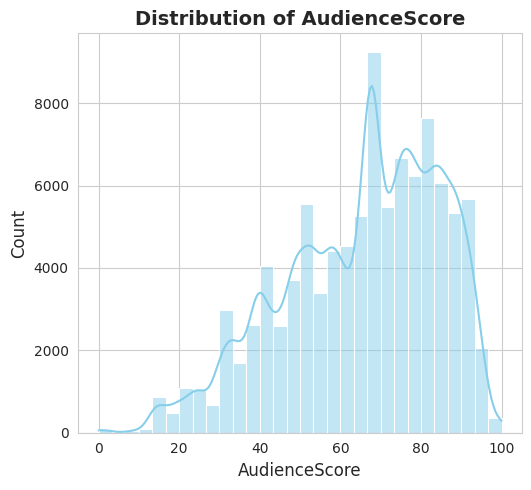

In [18]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(movies1['audienceScore'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of AudienceScore', fontsize=14, weight='bold')
plt.xlabel('AudienceScore', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

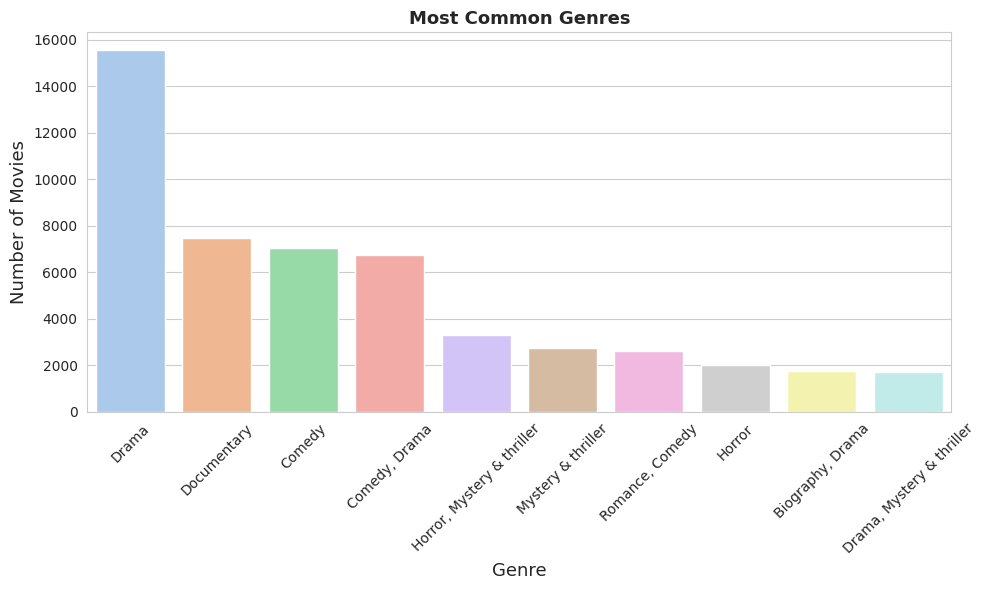

In [19]:
genre_df = (
    movies1['genre']
    .dropna()
    .str.split('|')
    .explode()
    .value_counts()
    .reset_index()
)
genre_df.columns = ['Genre', 'Count']

plt.figure(figsize = (10,6))
sns.barplot(
    data=genre_df.head(10),
    x='Genre',
    y='Count',
    hue='Genre',
    legend=False,
    palette='pastel'
)
plt.title("Most Common Genres", fontsize=13, weight='bold')
plt.xlabel("Genre", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

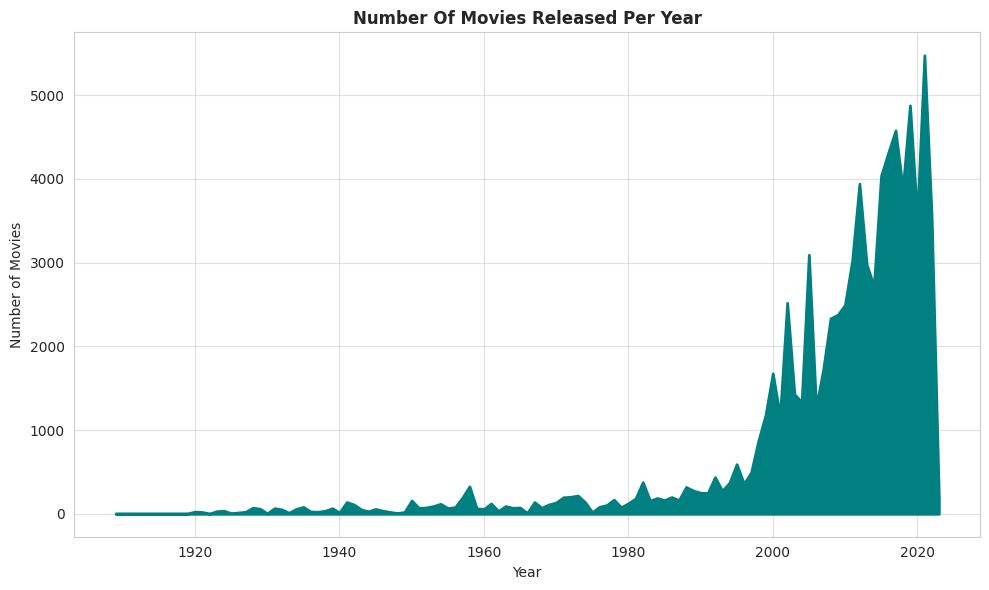

In [20]:
# Convert releaseDateTheaters to datetime
movies1['releaseDateTheaters'] = pd.to_datetime(
    movies1['releaseDateTheaters'],
    errors='coerce',
    format='mixed'
)

# Extract year from releaseDateTheaters
movies1['release_year'] = movies1['releaseDateTheaters'].dt.year
movies_per_year = movies1['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.fill_between(movies_per_year.index, movies_per_year.values, color='teal', linewidth=2)
plt.title("Number Of Movies Released Per Year", fontsize=12, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()
plt.show()

   release_year  movie_released  avg_audience_score
0        1909.0               4           68.000000
1        1916.0               4           70.000000
2        1919.0               4           50.000000
3        1920.0              26           70.269231
4        1921.0              21           61.714286


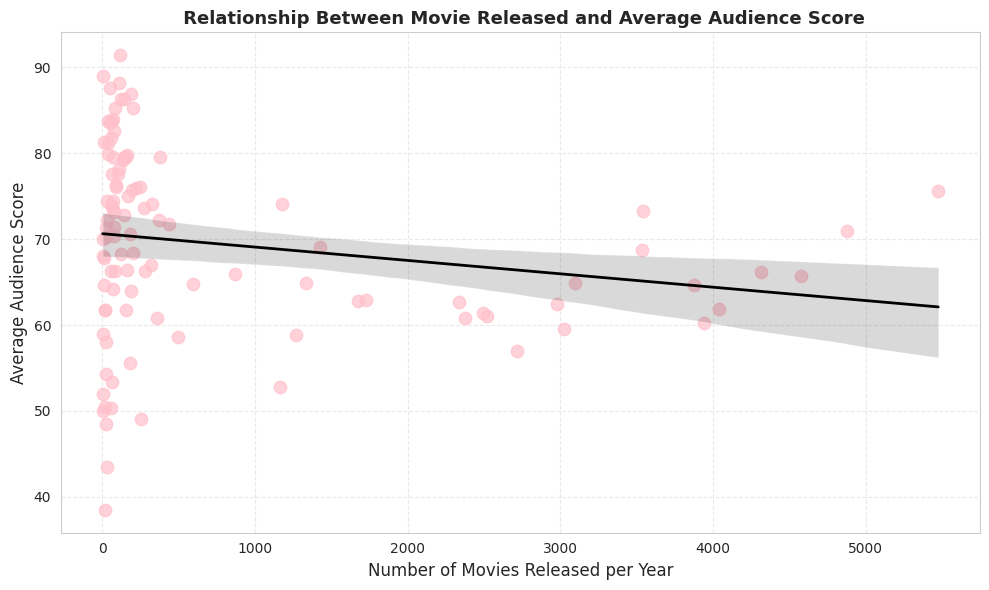

In [21]:
yearly_stat = (movies1.groupby('release_year')
               .agg(movie_released = ('title', 'count'),
                    avg_audience_score = ('audienceScore', 'mean')).reset_index()
               .dropna(subset = ['release_year'])
              )
print(yearly_stat.head())

plt.figure(figsize=(10,6))
sns.regplot(
    data = yearly_stat,
    x = 'movie_released',
    y = 'avg_audience_score',
    scatter_kws = {'color' : 'pink', 's' : 80, 'alpha' : 0.7},
    line_kws ={'color' : 'black', 'lw' : 2}
)

plt.title(" Relationship Between Movie Released and Average Audience Score", fontsize=13, weight='bold')
plt.xlabel("Number of Movies Released per Year", fontsize=12)
plt.ylabel("Average Audience Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


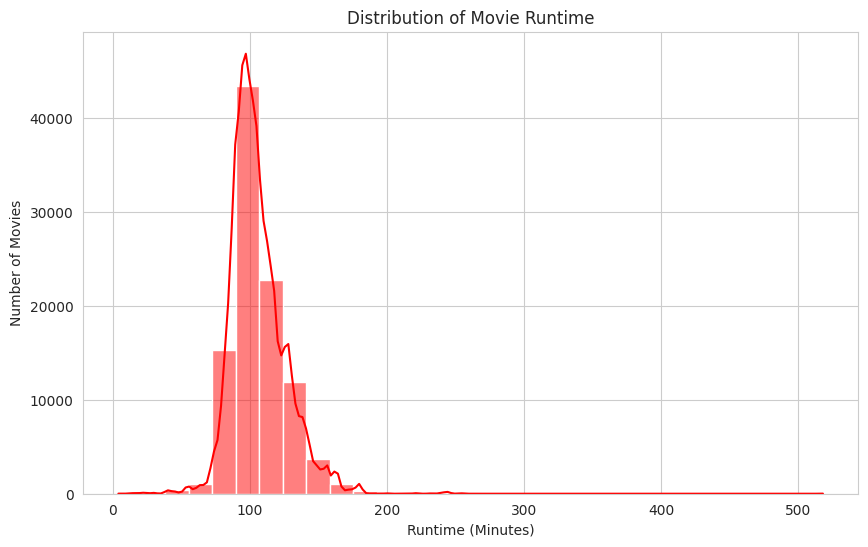

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(movies1['runtimeMinutes'], bins=30, kde=True, color='red')
plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

In [23]:
movies1.columns

Index(['id', 'title', 'audienceScore', 'releaseDateTheaters',
       'releaseDateStreaming', 'runtimeMinutes', 'genre', 'originalLanguage',
       'director', 'reviewId', 'criticName', 'isTopCritic', 'originalScore',
       'reviewState', 'publicatioName', 'reviewText', 'scoreSentiment',
       'release_year'],
      dtype='object')

<Figure size 1200x720 with 0 Axes>

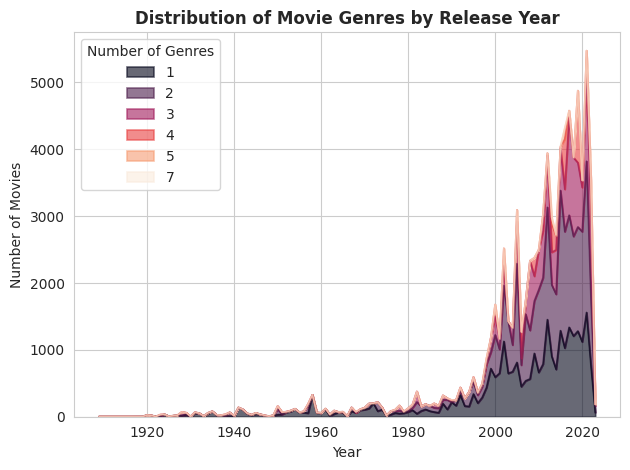

In [24]:
movies1['release_year'] = pd.to_datetime(
    movies1['releaseDateTheaters'], errors='coerce'
).dt.year

movies1['genre_list'] = movies1['genre'].fillna('Unknown').str.split(',')
movies1['num_genres'] = movies1['genre_list'].apply(len)

movies_genre_year = movies1.dropna(subset=['release_year'])
area_data = movies_genre_year.pivot_table(
    index='release_year',
    columns='num_genres',
    aggfunc='size',
    fill_value=0
)

sns.set_style("whitegrid")
plt.figure(figsize=(10,6), dpi=120)
area_data.plot.area(
    cmap=sns.color_palette("rocket", as_cmap=True),
    alpha=0.6, linewidth=1.2)
plt.title("Distribution of Movie Genres by Release Year", fontsize=12, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.legend(title='Number of Genres', loc='upper left')
plt.tight_layout()
plt.show()

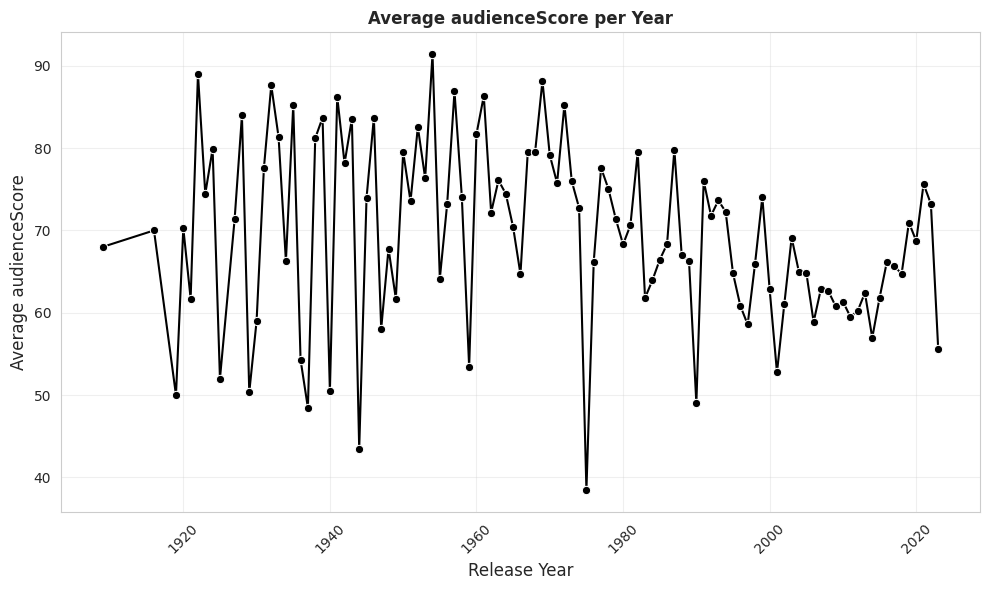

In [25]:
ratings_per_year = movies1.groupby('release_year')['audienceScore'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=ratings_per_year, x='release_year', y='audienceScore', marker='o', color='black')
plt.title("Average audienceScore per Year", fontsize=12, weight='bold')
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Average audienceScore", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

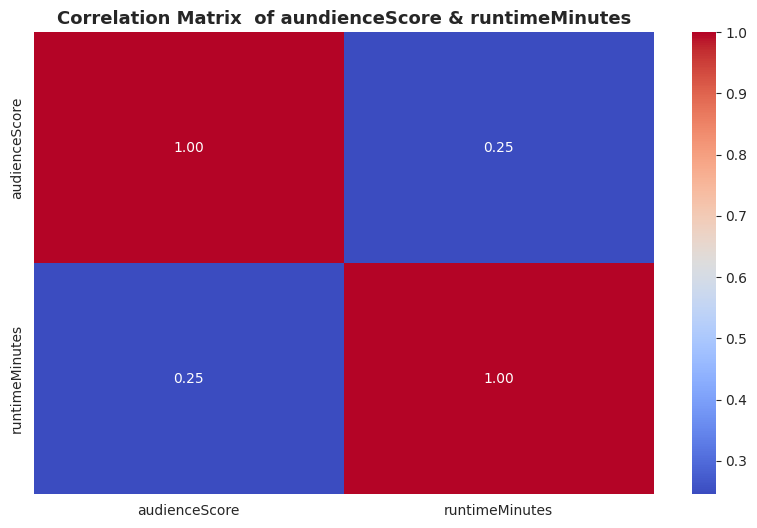

In [26]:
num_col=['audienceScore','runtimeMinutes']
corr_matrix=movies1[num_col].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix  of aundienceScore & runtimeMinutes", fontsize=13, weight='bold')
plt.show()

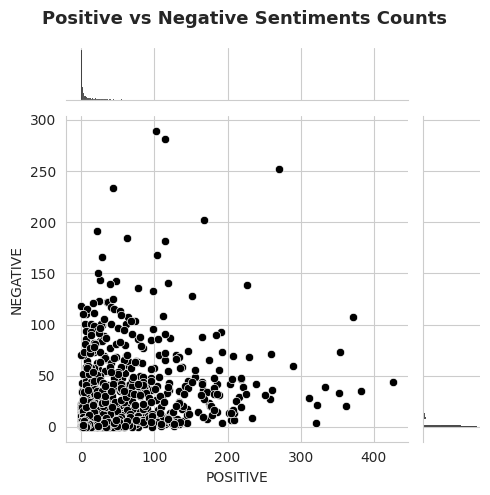

In [27]:
sentiment_counts = movies1.groupby('title')['scoreSentiment'].value_counts().unstack(fill_value=0)
sentiment_counts = sentiment_counts[['POSITIVE','NEGATIVE']]
sentiment_counts.head()
sns.jointplot(
    x='POSITIVE',
    y='NEGATIVE',
    data=sentiment_counts,
    kind='scatter',
    color='black',
    height=5
)

plt.suptitle("Positive vs Negative Sentiments Counts", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

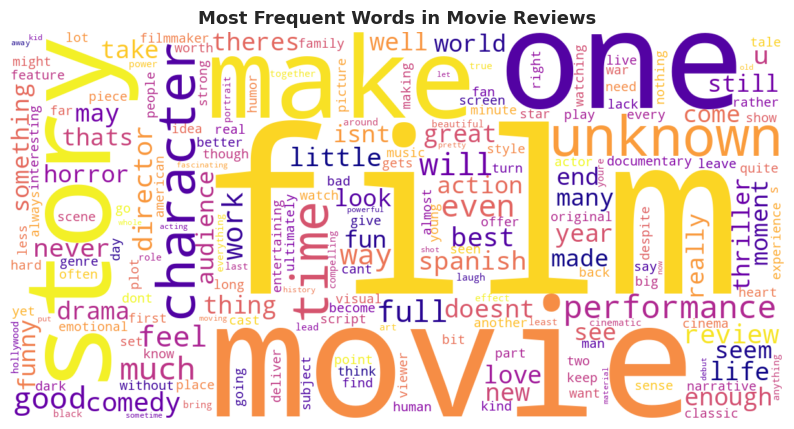

In [28]:
text= ' '.join(movies1['reviewText'].dropna().astype(str))
text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='plasma',
    max_words=200,
    collocations=False
).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Movie Reviews", fontsize=13, weight='bold')
plt.show()

In [29]:
movie_reviews = movies1.groupby('title')['reviewText'].apply(lambda x: ' '.join(x)).reset_index()

In [30]:
movie_info = movies1.drop_duplicates(subset='title')[['title', 'genre', 'runtimeMinutes', 'audienceScore', 'director']]

movies_combined = pd.merge(movie_info, movie_reviews, on='title')

In [31]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
tfidf_matrix = tfidf.fit_transform(movies_combined['reviewText'].fillna(''))

In [32]:
movies_combined['genre_list'] = movies_combined['genre'].fillna('').str.split(',')
mlb = MultiLabelBinarizer(sparse_output=True)
genre_matrix = mlb.fit_transform(movies_combined['genre_list'])

lb_director = LabelBinarizer(sparse_output=True)

director_matrix = lb_director.fit_transform(movies_combined['director'].fillna('Unknown'))

In [33]:
scaler = MinMaxScaler()
num_features = scaler.fit_transform(movies_combined[['runtimeMinutes', 'audienceScore']].fillna(0))
num_sparse = csr_matrix(num_features)

In [34]:
combined_features = hstack([tfidf_matrix, genre_matrix, director_matrix, num_sparse])

movie_indices = pd.Series(movies_combined.index, index=movies_combined['title']).drop_duplicates()

train_movies, test_movies = train_test_split(movies_combined, test_size=0.2, random_state=42)

test_title = test_movies.iloc[0]['title']
print("Testing recommendations for:", test_title)

# Compute cosine similarity for that test movie
idx = movie_indices[test_title]
sim_scores = cosine_similarity(combined_features[idx], combined_features).flatten()


Testing recommendations for: The Chronicles of Riddick


In [35]:
# Get top 5 most similar movies
top_indices = sim_scores.argsort()[-6:-1][::-1]
recommended_movies = movies_combined.iloc[top_indices][['title', 'genre', 'director', 'audienceScore']]
print("\nTop 5 recommended movies for:", test_title)
display(recommended_movies)

# Calculate average similarity score
avg_similarity = np.mean(sim_scores[top_indices])
print(f"\nAverage Cosine Similarity Score: {avg_similarity:.3f}")


Top 5 recommended movies for: The Chronicles of Riddick


,title,genre,director,audienceScore
1655,War of the Worlds,"Sci-fi, Adventure, Action",Steven Spielberg,42.0
2745,Star Wars: Episode II -- Attack of the Clones,"Sci-fi, Adventure, Action, Fantasy",George Lucas,56.0
2677,Star Wars: The Rise of Skywalker,"Sci-fi, Adventure, Action, Fantasy",J.J. Abrams,86.0
3606,Dune,"Sci-fi, Adventure",David Lynch,65.0
483,Bionicle: The Legend Reborn,"Sci-fi, Adventure, Action, Animation",Mark Baldo,54.0



Average Cosine Similarity Score: 0.618


In [36]:
# Recommendation function
def recommend(title=None, genres=None, top_n=5):
    if title:
        matches = movies_combined[movies_combined['title'].str.lower().str.contains(title.lower())]
        if matches.empty:
            return f" Movie '{title}' not found in dataset."

        idx = matches.index[0]
        sim_scores = linear_kernel(combined_features[idx], combined_features).flatten()
        sim_indices = sim_scores.argsort()[::-1]
        sim_indices = [i for i in sim_indices if i != idx][:top_n]

        recs = movies_combined.iloc[sim_indices][['title', 'genre', 'director', 'audienceScore']].copy()

        if genres:
            genres = [g.strip().lower() for g in genres.split(',')]
            recs = recs[recs['genre'].apply(lambda x: any(g in x.lower() for g in genres))]
            if recs.empty:
                return f"No matches found for title '{title}' with genres {genres}"
        return recs.reset_index(drop=True)

    elif genres:
        genres = [g.strip().lower() for g in genres.split(',')]
        filtered = movies_combined[movies_combined['genre'].apply(lambda x: any(g in x.lower() for g in genres))]
        if filtered.empty:
            return f"No movies found with genres: {genres}"
        return filtered[['title', 'genre', 'director', 'audienceScore']].head(top_n).reset_index(drop=True)
    else:
        return " Please enter either a movie title or genre(s)!"


In [37]:
from ipywidgets import interact, widgets
from IPython.display import display

# Define the text box
title_input = widgets.Text(
    value='',
    placeholder='Enter a movie name',
    description='🎬 Title:',
    disabled=False
)

genre_input = widgets.Text(
    value='',

    placeholder='Enter genres',
    description='🎭 Genre:',
    disabled=False
)

# Buttons for recommendation
button = widgets.Button(description="Get Recommendations", button_style='success')
output = widgets.Output()

display(title_input, genre_input, button, output)

def on_button_click(b):
    with output:
        output.clear_output()
        title = title_input.value.strip()
        genres = genre_input.value.strip()
        print(f"\n🎬 Recommendations based on:", end=" ")
        if title: print(f"title = '{title}'", end=" ")
        if genres: print(f"and genres = '{genres}'")
        print("\n")
        recs = recommend(title if title else None, genres if genres else None, top_n=5)
        display(recs)

button.on_click(on_button_click)

Text(value='', description='🎬 Title:', placeholder='Enter a movie name')

Text(value='', description='🎭 Genre:', placeholder='Enter genres')

Button(button_style='success', description='Get Recommendations', style=ButtonStyle())

Output()